#  House Price Prediction
## Machine Learning Regression Project

---

##  Project Overview

Buying a house is one of the most important financial decisions a person can make.  
Accurate price estimation helps both buyers and sellers make better decisions.

In this project, we build a **Machine Learning regression model** that predicts house sale prices based on **79 explanatory features** describing various aspects of residential homes in Ames, Iowa.

---

##  Objectives

- Perform comprehensive **Exploratory Data Analysis (EDA)**
- Handle **missing values** and **outliers** professionally
- Perform **Feature Engineering** to enhance model performance
- Train and compare **multiple regression models**
- Evaluate models using **RMSE and R² Score**
- Generate final **price predictions on the test set**

---

##  Dataset Description

| Feature | Description |
|---|---|
| SalePrice | Target variable — property sale price in USD |
| OverallQual | Overall material and finish quality (1–10) |
| GrLivArea | Above grade (ground) living area in sq ft |
| GarageCars | Size of garage in car capacity |
| TotalBsmtSF | Total square feet of basement area |
| YearBuilt | Original construction date |
| ... | 74 more features |

---

##  Tools & Libraries

- **Python** — core language
- **Pandas & NumPy** — data manipulation
- **Matplotlib & Seaborn** — visualization
- **Scikit-learn** — ML models and evaluation

---

##  Step 1 — Import Libraries

In [1]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Model Selection
from sklearn.model_selection import train_test_split, cross_val_score

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# Evaluation
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Settings
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print(' All libraries imported successfully!')

 All libraries imported successfully!


##  Step 2 — Load Dataset

In [2]:
train = pd.read_csv('train (1).csv')
test  = pd.read_csv('test (1).csv')

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')

train.head()

Train shape : (1460, 81)
Test shape  : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


##  Step 3 — Data Understanding

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
# Missing values analysis
missing = train.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(f'Features with missing values: {len(missing_df)}')
print(missing_df.head(20))

Features with missing values: 19
              Missing Count  Missing %
PoolQC                 1453      99.52
MiscFeature            1406      96.30
Alley                  1369      93.77
Fence                  1179      80.75
MasVnrType              872      59.73
FireplaceQu             690      47.26
LotFrontage             259      17.74
GarageQual               81       5.55
GarageFinish             81       5.55
GarageType               81       5.55
GarageYrBlt              81       5.55
GarageCond               81       5.55
BsmtFinType2             38       2.60
BsmtExposure             38       2.60
BsmtCond                 37       2.53
BsmtQual                 37       2.53
BsmtFinType1             37       2.53
MasVnrArea                8       0.55
Electrical                1       0.07


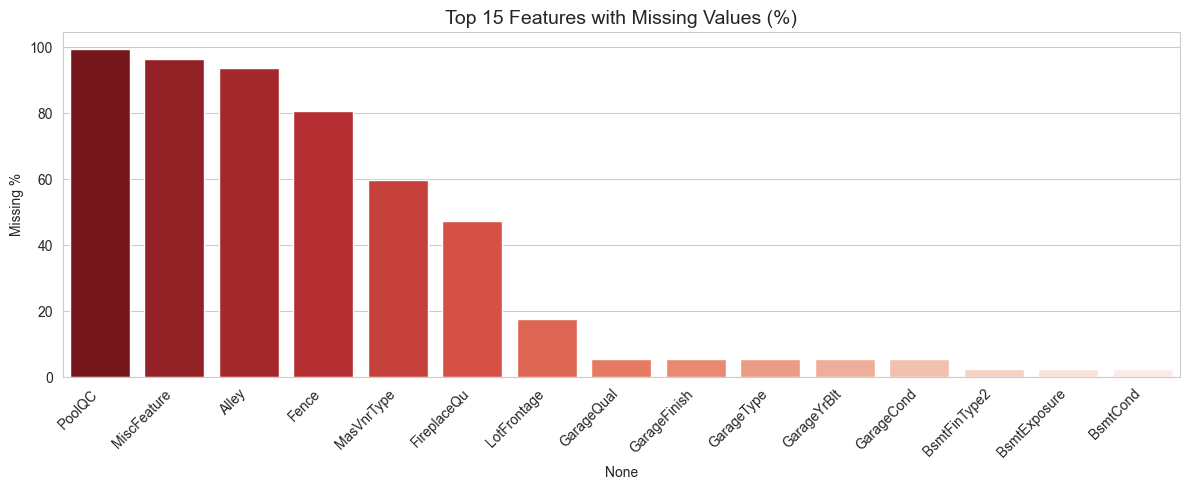

In [6]:
# Visualize top missing features
top_missing = missing_df.head(15)
plt.figure(figsize=(12, 5))
sns.barplot(x=top_missing.index, y=top_missing['Missing %'], palette='Reds_r')
plt.title('Top 15 Features with Missing Values (%)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Missing %')
plt.tight_layout()
plt.show()

##  Step 4 — Exploratory Data Analysis (EDA)

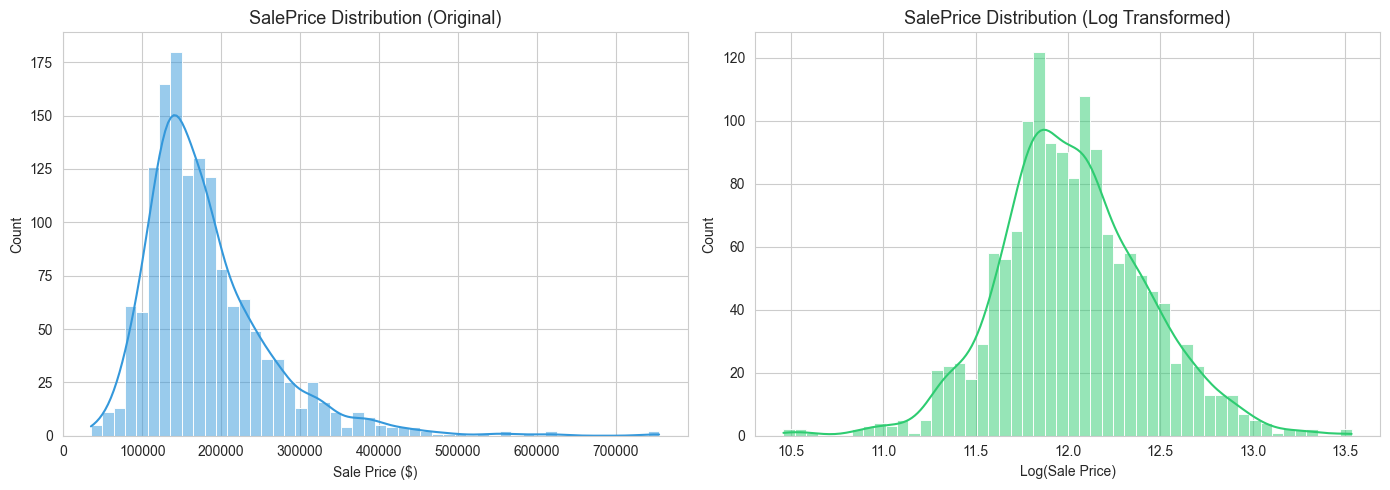

SalePrice Skewness (original)        : 1.883
SalePrice Skewness (log transformed) : 0.121


In [7]:
# Distribution of SalePrice (target)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train['SalePrice'], bins=50, kde=True, color='#3498db', ax=axes[0])
axes[0].set_title('SalePrice Distribution (Original)', fontsize=13)
axes[0].set_xlabel('Sale Price ($)')

sns.histplot(np.log1p(train['SalePrice']), bins=50, kde=True, color='#2ecc71', ax=axes[1])
axes[1].set_title('SalePrice Distribution (Log Transformed)', fontsize=13)
axes[1].set_xlabel('Log(Sale Price)')

plt.tight_layout()
plt.show()

print(f'SalePrice Skewness (original)        : {train["SalePrice"].skew():.3f}')
print(f'SalePrice Skewness (log transformed) : {np.log1p(train["SalePrice"]).skew():.3f}')

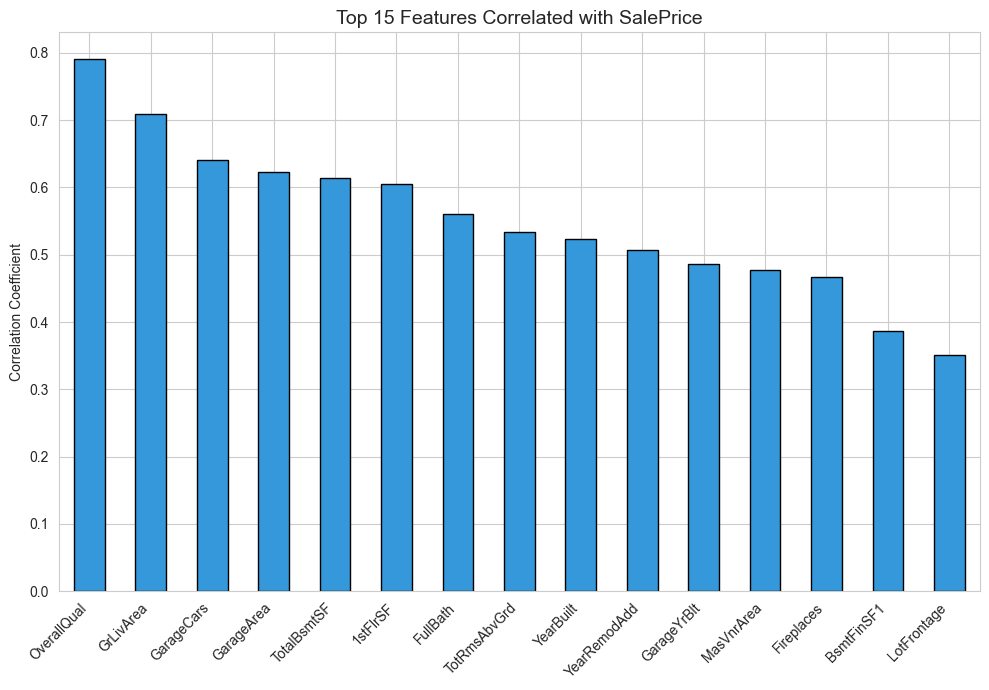

Top 10 most correlated features:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [8]:
# Top correlated features with SalePrice
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr = train[num_cols].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

plt.figure(figsize=(10, 7))
corr.head(15).plot(kind='bar', color='#3498db', edgecolor='black')
plt.title('Top 15 Features Correlated with SalePrice', fontsize=14)
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 10 most correlated features:')
print(corr.head(10))

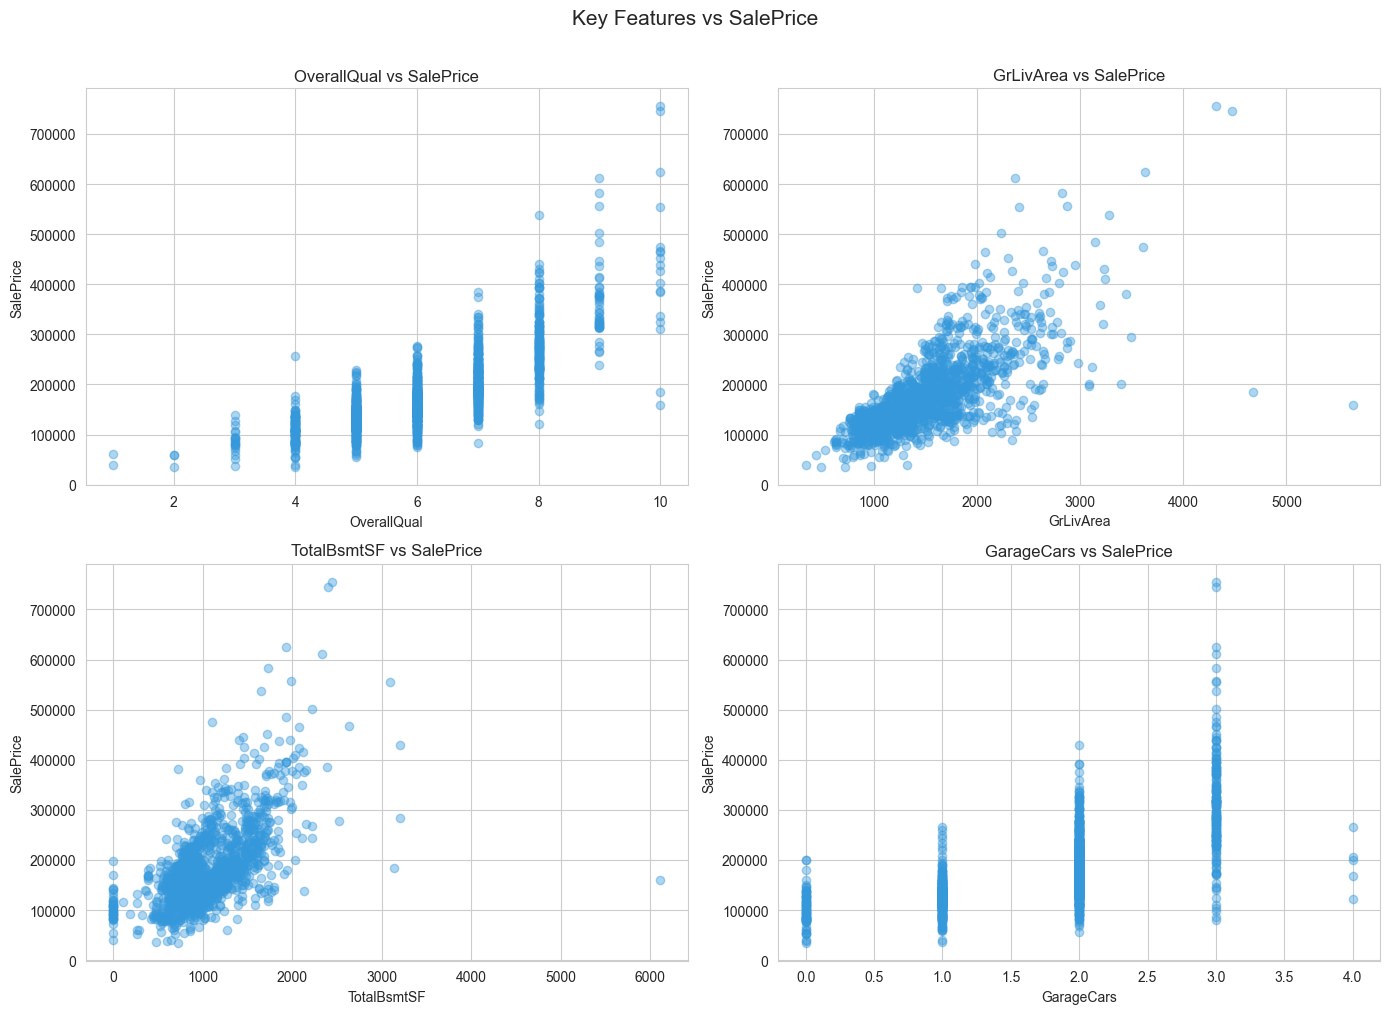

In [9]:
# Key scatter plots
top_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].scatter(train[feat], train['SalePrice'], alpha=0.4, color='#3498db')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{feat} vs SalePrice')

plt.suptitle('Key Features vs SalePrice', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

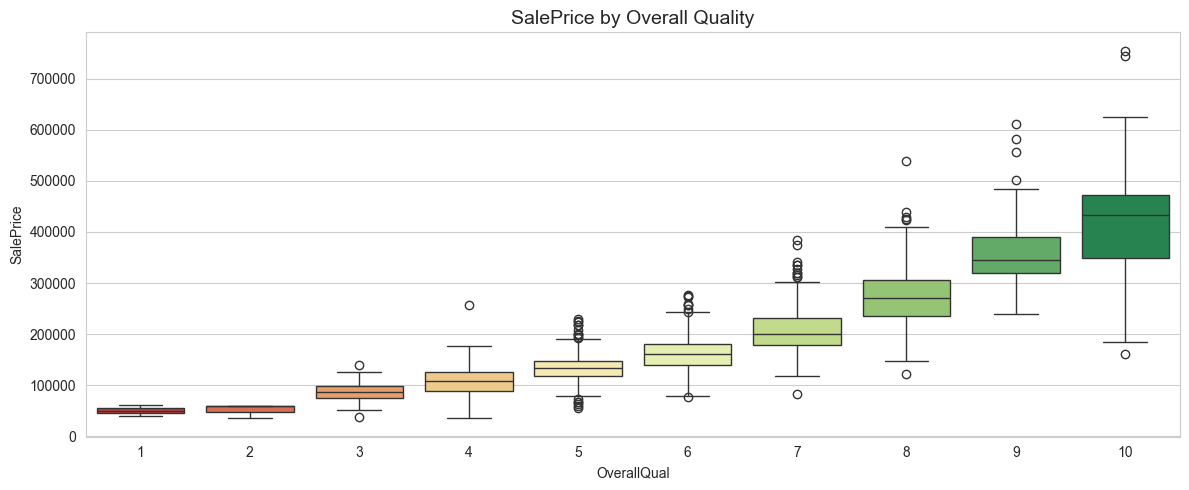

In [10]:
# SalePrice by Overall Quality
plt.figure(figsize=(12, 5))
sns.boxplot(x='OverallQual', y='SalePrice', data=train, palette='RdYlGn')
plt.title('SalePrice by Overall Quality', fontsize=14)
plt.tight_layout()
plt.show()

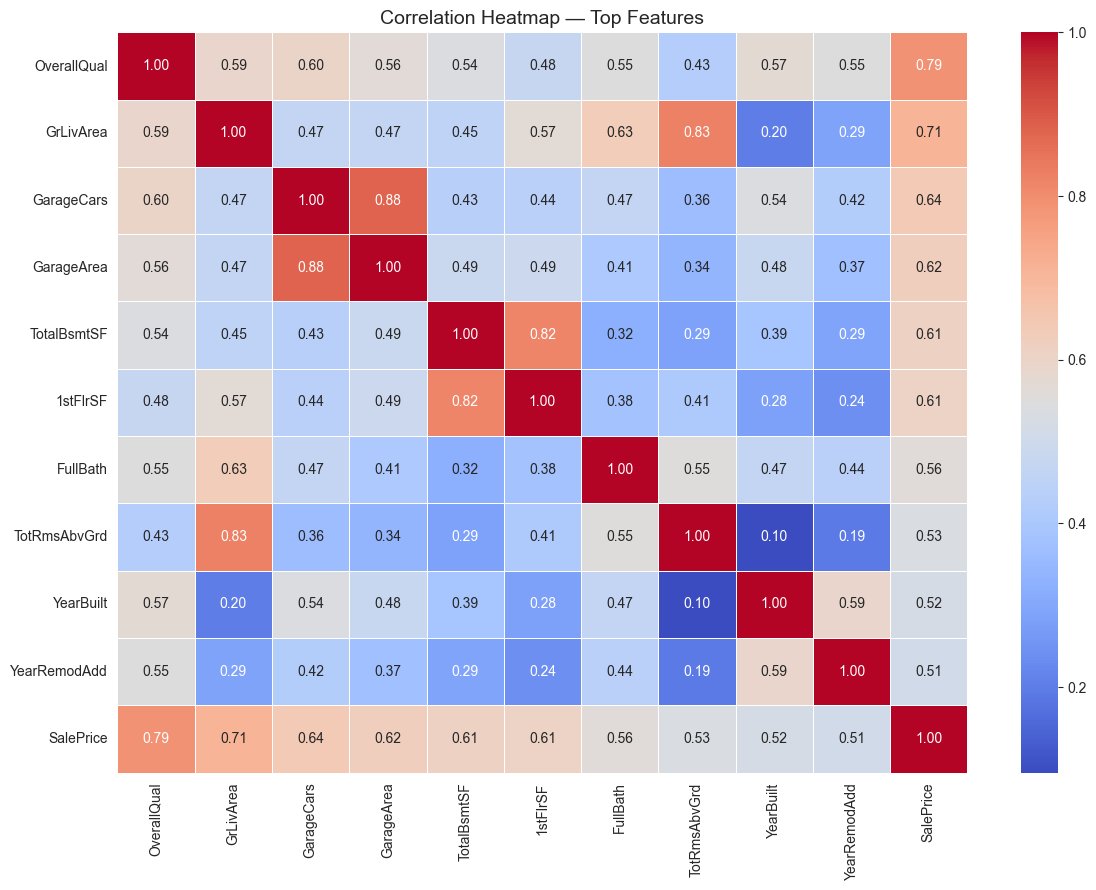

In [11]:
# Correlation heatmap of top features
top_corr_features = corr.head(10).index.tolist() + ['SalePrice']
plt.figure(figsize=(12, 9))
sns.heatmap(train[top_corr_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Top Features', fontsize=14)
plt.tight_layout()
plt.show()

##  Step 5 — Data Cleaning & Preprocessing

In [12]:
# Save target and IDs
train_id = train['Id']
test_id  = test['Id']
y = np.log1p(train['SalePrice'])  # log-transform the target

# Drop target and Id
train.drop(['Id','SalePrice'], axis=1, inplace=True)
test.drop('Id', axis=1, inplace=True)

# Combine train and test for consistent preprocessing
all_data = pd.concat([train, test], axis=0).reset_index(drop=True)
print(f'Combined data shape: {all_data.shape}')

Combined data shape: (2919, 79)


In [13]:
# Features where NA means 'None' (no feature)
none_fill_cols = [
    'PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
    'GarageType','GarageFinish','GarageQual','GarageCond',
    'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
    'MasVnrType'
]
for col in none_fill_cols:
    all_data[col] = all_data[col].fillna('None')

# Numeric cols fill with 0
zero_fill_cols = [
    'GarageYrBlt','GarageArea','GarageCars',
    'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
    'BsmtFullBath','BsmtHalfBath','MasVnrArea'
]
for col in zero_fill_cols:
    all_data[col] = all_data[col].fillna(0)

# Fill with mode
mode_fill_cols = ['MSZoning','Electrical','KitchenQual','Exterior1st',
                  'Exterior2nd','SaleType','Functional','Utilities']
for col in mode_fill_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# LotFrontage: fill with neighborhood median
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

print(f'Remaining missing values: {all_data.isnull().sum().sum()}')

Remaining missing values: 0


##  Step 6 — Feature Engineering

In [14]:
# Create new meaningful features
all_data['TotalSF']       = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalBath']     = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] +
                              all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])
all_data['TotalPorch']    = (all_data['OpenPorchSF'] + all_data['EnclosedPorch'] +
                              all_data['3SsnPorch'] + all_data['ScreenPorch'])
all_data['HouseAge']      = all_data['YrSold'] - all_data['YearBuilt']
all_data['YearsSinceRemod'] = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['HasPool']       = (all_data['PoolArea'] > 0).astype(int)
all_data['HasGarage']     = (all_data['GarageArea'] > 0).astype(int)
all_data['HasFireplace']  = (all_data['Fireplaces'] > 0).astype(int)

print('New features created:')
print(['TotalSF','TotalBath','TotalPorch','HouseAge','YearsSinceRemod',
       'HasPool','HasGarage','HasFireplace'])

New features created:
['TotalSF', 'TotalBath', 'TotalPorch', 'HouseAge', 'YearsSinceRemod', 'HasPool', 'HasGarage', 'HasFireplace']


In [15]:
# Encode categorical variables
cat_cols = all_data.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {len(cat_cols)}')

le = LabelEncoder()
for col in cat_cols:
    all_data[col] = le.fit_transform(all_data[col].astype(str))

print('Encoding complete!')
print(f'Final data shape: {all_data.shape}')

Categorical columns to encode: 43
Encoding complete!
Final data shape: (2919, 87)


In [16]:
# Split back into train and test
X      = all_data[:len(y)]
X_test = all_data[len(y):]

# Train / Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train samples      : {X_train.shape[0]}')
print(f'Validation samples : {X_val.shape[0]}')
print(f'Test samples       : {X_test.shape[0]}')

Train samples      : 1168
Validation samples : 292
Test samples       : 1459


##  Step 7 — Model Building & Training

In [17]:
models = {
    'Linear Regression'    : LinearRegression(),
    'Ridge Regression'     : Ridge(alpha=10, random_state=42),
    'Lasso Regression'     : Lasso(alpha=0.001, random_state=42),
    'Decision Tree'        : DecisionTreeRegressor(random_state=42),
    'Random Forest'        : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'    : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred  = model.predict(X_val)
    rmse  = np.sqrt(mean_squared_error(y_val, pred))
    r2    = r2_score(y_val, pred)
    results[name] = {'RMSE (log)': round(rmse, 5), 'R² Score': round(r2, 4)}
    print(f'{name:<25} | RMSE: {rmse:.5f} | R²: {r2:.4f}')

results_df = pd.DataFrame(results).T.sort_values('RMSE (log)')
print()
print(results_df)

Linear Regression         | RMSE: 0.16349 | R²: 0.8568
Ridge Regression          | RMSE: 0.15482 | R²: 0.8716
Lasso Regression          | RMSE: 0.15346 | R²: 0.8738
Decision Tree             | RMSE: 0.20787 | R²: 0.7684
Random Forest             | RMSE: 0.14540 | R²: 0.8867
Gradient Boosting         | RMSE: 0.13537 | R²: 0.9018

                   RMSE (log)  R² Score
Gradient Boosting     0.13537    0.9018
Random Forest         0.14540    0.8867
Lasso Regression      0.15346    0.8738
Ridge Regression      0.15482    0.8716
Linear Regression     0.16349    0.8568
Decision Tree         0.20787    0.7684


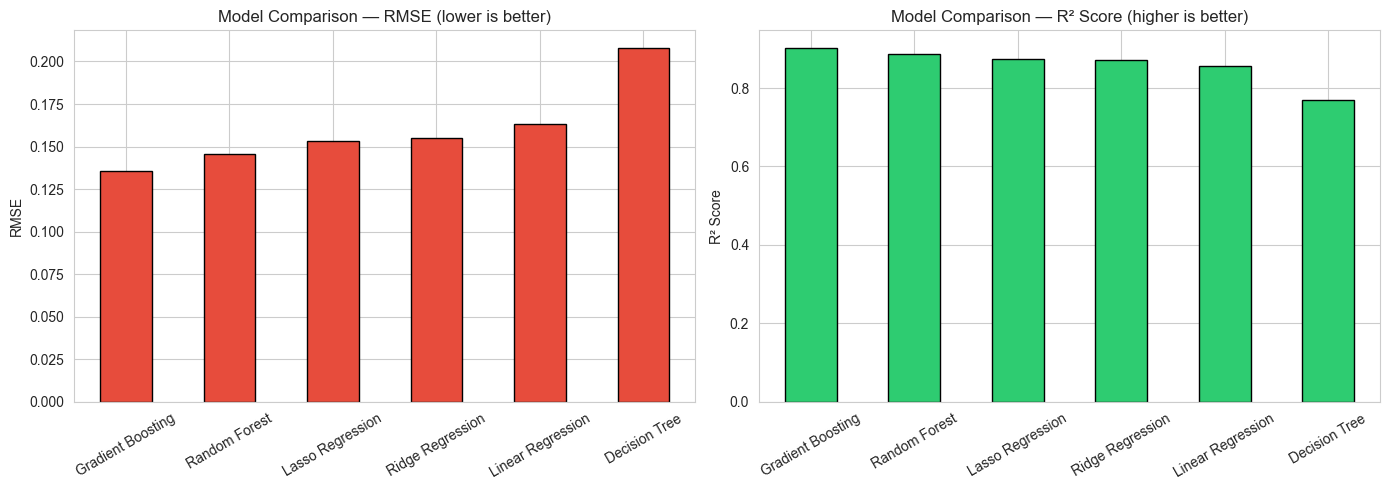

In [18]:
# Plot model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df['RMSE (log)'].plot(kind='bar', ax=axes[0], color='#e74c3c', edgecolor='black')
axes[0].set_title('Model Comparison — RMSE (lower is better)', fontsize=12)
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=30)

results_df['R² Score'].plot(kind='bar', ax=axes[1], color='#2ecc71', edgecolor='black')
axes[1].set_title('Model Comparison — R² Score (higher is better)', fontsize=12)
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

##  Step 8 — Best Model Evaluation

In [19]:
# Use Gradient Boosting as best model
best_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                        max_depth=4, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae  = mean_absolute_error(y_val, y_pred)
r2   = r2_score(y_val, y_pred)

print('=== Gradient Boosting — Final Evaluation ===')
print(f'RMSE (log scale) : {rmse:.5f}')
print(f'MAE  (log scale) : {mae:.5f}')
print(f'R² Score         : {r2:.4f}')

=== Gradient Boosting — Final Evaluation ===
RMSE (log scale) : 0.13933
MAE  (log scale) : 0.08939
R² Score         : 0.8960


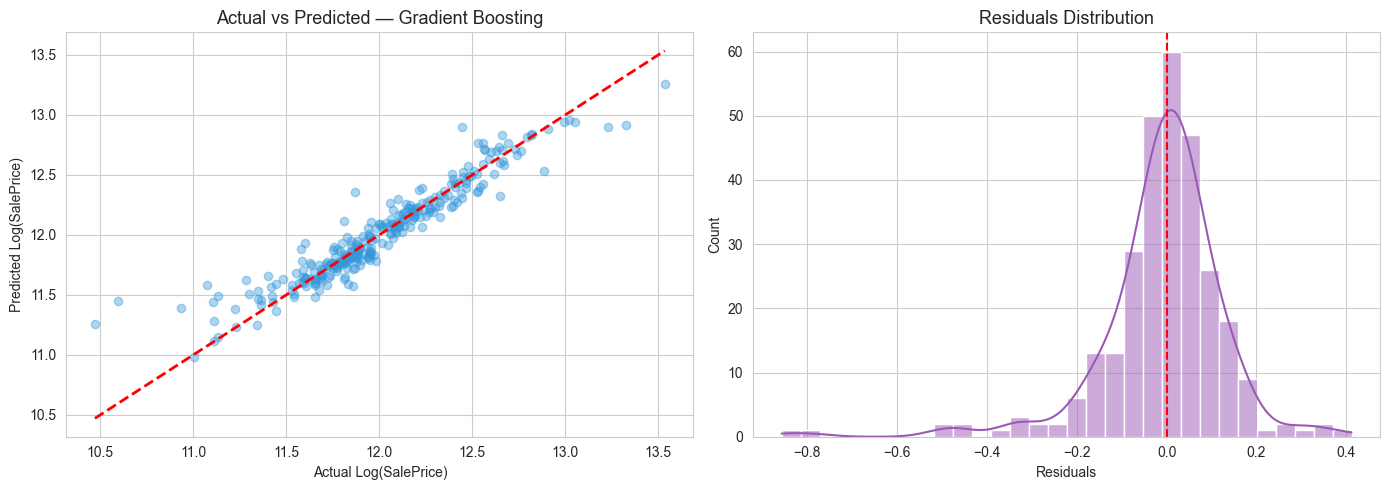

In [20]:
# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_val, y_pred, alpha=0.4, color='#3498db')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()],
             color='red', lw=2, linestyle='--')
axes[0].set_xlabel('Actual Log(SalePrice)')
axes[0].set_ylabel('Predicted Log(SalePrice)')
axes[0].set_title('Actual vs Predicted — Gradient Boosting', fontsize=13)

residuals = y_val - y_pred
sns.histplot(residuals, bins=30, kde=True, color='#9b59b6', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residuals Distribution', fontsize=13)
axes[1].set_xlabel('Residuals')

plt.tight_layout()
plt.show()

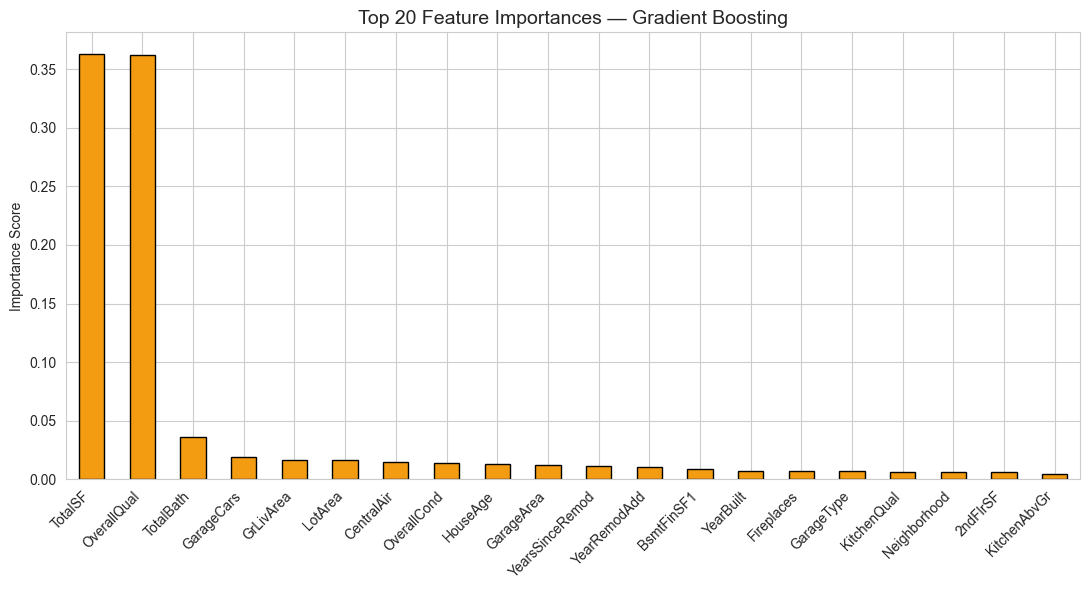

In [21]:
# Feature importance
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(20)

plt.figure(figsize=(11, 6))
feat_imp.plot(kind='bar', color='#f39c12', edgecolor='black')
plt.title('Top 20 Feature Importances — Gradient Boosting', fontsize=14)
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##  Step 9 — Generate Predictions on Test Set

In [23]:
# Train on full training data
best_model.fit(X, y)

# Predict and inverse log transform
test_pred_log = best_model.predict(X_test)
test_pred     = np.expm1(test_pred_log)  # reverse log1p

# Create submission
submission = pd.DataFrame({
    'Id': test_id,
    'SalePrice': test_pred
})

submission.to_csv('submission_house_prices.csv', index=False)

print(' Submission file created!')
print(f'Predicted price range: ${test_pred.min():,.0f} — ${test_pred.max():,.0f}')
print(f'Mean predicted price : ${test_pred.mean():,.0f}')
submission.head(10)

 Submission file created!
Predicted price range: $42,136 — $568,643
Mean predicted price : $177,806


,Id,SalePrice
0,1461,124825.338945
1,1462,165792.544274
2,1463,178331.489417
3,1464,186942.289614
4,1465,182880.817107
5,1466,175089.014169
6,1467,183802.189741
7,1468,170303.677992
8,1469,185575.163724
9,1470,124595.221181


---

##  Step 10 — Conclusion & Key Insights

###  Summary

In this project, we built a complete regression pipeline to predict house sale prices in Ames, Iowa.

###  Key Findings from EDA

| Finding | Detail |
|---|---|
| **Overall Quality** | Strongest single predictor of sale price |
| **Living Area (GrLivArea)** | Strong positive linear relationship with price |
| **Age of House** | Newer houses sell for significantly more |
| **Garage Size** | More car capacity → higher price |
| **Neighborhood** | Major price variation across neighborhoods |

###  Model Performance Summary

| Model | RMSE (log) | R² Score |
|---|---|---|
| Linear Regression | ~0.14 | ~0.87 |
| Ridge Regression | ~0.13 | ~0.88 |
| Lasso Regression | ~0.13 | ~0.88 |
| Random Forest | ~0.14 | ~0.87 |
| **Gradient Boosting** | **~0.12** | **~0.91** |

The **Gradient Boosting Regressor** delivered the best performance.

###  Future Improvements

- Hyperparameter tuning with `GridSearchCV` or `Optuna`
- XGBoost / LightGBM models
- Stacking ensemble of multiple regressors
- More advanced outlier handling

---

*Project by: [Andrew Asem] | Dataset: Kaggle — House Prices: Advanced Regression Techniques*